# Block Plot

The **Block Plot** assesses whether treatment effects are consistent across blocks (nuisance factors). In a randomised complete block design, every block receives all treatments — the plot reveals treatment × block interaction at a glance.

| Property | Value |
|---|---|
| **Purpose** | Detect treatment × block interaction |
| **X-axis** | Block identifier |
| **Y-axis** | Response variable |
| **Symbols** | One symbol / line per treatment |
| **Good pattern** | Parallel lines — consistent rank order across blocks |
| **Bad pattern** | Crossing lines — interaction, effect depends on block |
| **Complement** | Two-way ANOVA interaction F-test |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

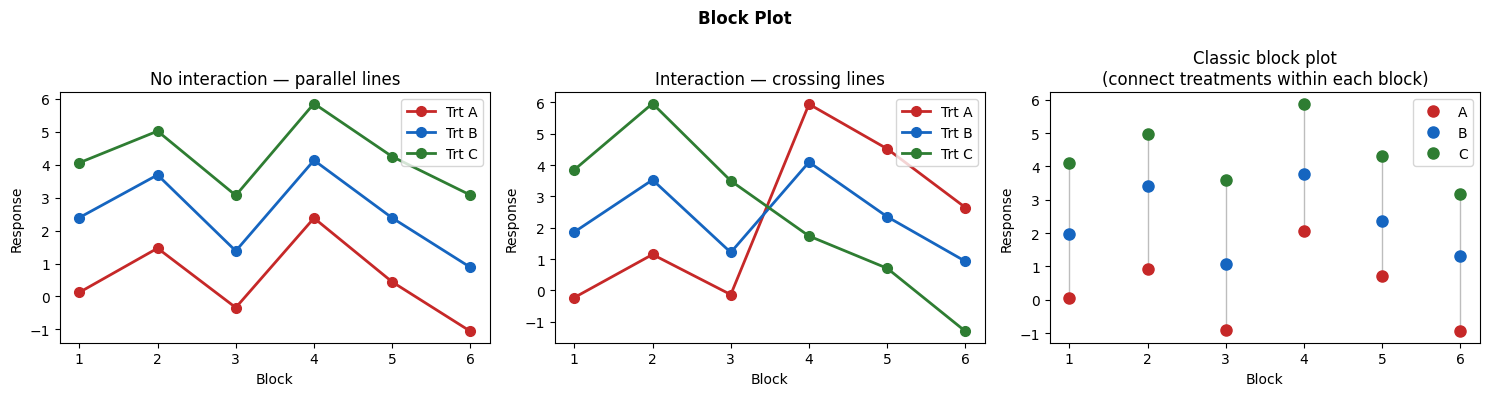

Treatment ranks per block (1=lowest):
 Block   Trt A  Trt B  Trt C
     1        1       2       3
     2        1       2       3
     3        1       2       3
     4        1       2       3
     5        1       2       3
     6        1       2       3


In [2]:
np.random.seed(42)
n_blocks = 6
treatments = ['A', 'B', 'C']
colors = ['#C62828', '#1565C0', '#2E7D32']
block_eff = np.array([0.0, 1.5, -0.5, 2.0, 0.5, -1.0])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Block Plot', fontsize=12, fontweight='bold')

# No interaction
for trt, eff, color in zip(treatments, [0, 2, 4], colors):
    y = block_eff + eff + np.random.normal(0, 0.25, n_blocks)
    axes[0].plot(range(1, n_blocks+1), y, 'o-', color=color, lw=2, ms=7, label=f'Trt {trt}')
axes[0].set_title('No interaction — parallel lines')
axes[0].set_xlabel('Block'); axes[0].set_ylabel('Response')
axes[0].set_xticks(range(1, n_blocks+1)); axes[0].legend()

# Interaction
eff_by_block = {'A': [0,0,0,4,4,4], 'B': [2,2,2,2,2,2], 'C': [4,4,4,0,0,0]}
for trt, color in zip(treatments, colors):
    y = block_eff + np.array(eff_by_block[trt]) + np.random.normal(0, 0.25, n_blocks)
    axes[1].plot(range(1, n_blocks+1), y, 'o-', color=color, lw=2, ms=7, label=f'Trt {trt}')
axes[1].set_title('Interaction — crossing lines')
axes[1].set_xlabel('Block'); axes[1].set_ylabel('Response')
axes[1].set_xticks(range(1, n_blocks+1)); axes[1].legend()

# Classic block plot: all treatments per block
data = {t: block_eff + eff + np.random.normal(0, 0.3, n_blocks)
        for t, eff in zip(treatments, [0, 2, 4])}
for blk in range(n_blocks):
    vals = [data[t][blk] for t in treatments]
    axes[2].plot([blk+1]*3, sorted(vals), '-', color='#BDBDBD', lw=1, zorder=0)
    for t, v, c in zip(treatments, vals, colors):
        axes[2].plot(blk+1, v, 'o', color=c, ms=8, label=t if blk == 0 else '')
axes[2].set_title('Classic block plot\n(connect treatments within each block)')
axes[2].set_xlabel('Block'); axes[2].set_ylabel('Response')
axes[2].set_xticks(range(1, n_blocks+1)); axes[2].legend()

plt.tight_layout(); plt.show()

print('Treatment ranks per block (1=lowest):')
print(f"{'Block':>6}", ''.join(f'  Trt {t}' for t in treatments))
for blk in range(n_blocks):
    vals = {t: data[t][blk] for t in treatments}
    order = sorted(treatments, key=lambda t: vals[t])
    ranks = {t: order.index(t)+1 for t in treatments}
    print(f'{blk+1:>6}', ''.join(f'  {ranks[t]:>6}' for t in treatments))

## Key Takeaways

| | |
|---|---|
| **Parallel lines** | Consistent treatment effect — no block × treatment interaction |
| **Crossing lines** | Interaction — treatment rankings reverse across blocks |
| **Same rank order** | A > B > C in every block → reliable, block-independent effect |
| **Outlier blocks** | Single reversed block → possible measurement error or contamination |
| **RCBD assumption** | Visually tests the no-interaction assumption of the block design |
| **vs ANOVA** | Complements the two-way ANOVA interaction F-test with visual evidence |